# <H1 style = "text-align:center;color:red;background-color:black;">SPAM  DETECTION USING NLP</H1>

In [49]:
import pandas as pd 
import numpy as np 
from nltk import ngrams 
import contractions
from nltk.corpus import stopwords , wordnet
from nltk import pos_tag
from nltk.tokenize import word_tokenize,sent_tokenize
from nltk.stem import PorterStemmer , WordNetLemmatizer
from sklearn.model_selection import train_test_split
import spacy
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier , RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

In [50]:
nlp = spacy.load("en_core_web_sm")

In [51]:
df1 = pd.read_csv("SMSSpamCollection",sep="\t" ,names=["label" , "sentence"])

In [52]:
df1

,label,sentence
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [53]:
df1['label'] = df1['label'].replace({"ham":"not_spam"})

In [54]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   label     5572 non-null   object
 1   sentence  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [55]:
df1['label'].value_counts()

label
not_spam    4825
spam         747
Name: count, dtype: int64

In [56]:
import re 

In [57]:
df1['sentence'] = df1['sentence'].apply(contractions.fix)

In [58]:
def cleaning_text(text):
    text = text.casefold()
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    
    return text.strip()

df1['sentence'] = df1['sentence'].apply(cleaning_text)

In [59]:
df1

,label,sentence
0,not_spam,go until jurong point crazy available only in ...
1,not_spam,ok lar joking wif you oni
2,spam,free entry in 2 a wkly comp to win fa cup fina...
3,not_spam,you dun say so early hor you c already then say
4,not_spam,nah i do not think he goes to usf he lives aro...
...,...,...
5567,spam,this is the 2nd time we have tried 2 contact y...
5568,not_spam,will ü b going to esplanade fr home
5569,not_spam,pity was in mood for that so any other suggest...
5570,not_spam,the guy did some bitching but i acted like i w...


In [60]:
df1['sentence'] = df1['sentence'].apply(word_tokenize)

In [61]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

stop_words = set(stopwords.words("english"))

def cleaning_text_data(text):

    if isinstance(text, list):
        text = " ".join(text)

    text = text.lower()

    text = re.sub(r"[^\w\s]", " ", text)

    text = re.sub(r"\s+", " ", text)

    words = text.split()

    # remove stopwords
    words = [word for word in words if word not in stop_words]

    # lemmatization
    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words).strip()

In [62]:
df1['sentence'] = df1['sentence'].apply(cleaning_text_data)

In [63]:
df1

,label,sentence
0,not_spam,go jurong point crazy available bugis n great ...
1,not_spam,ok lar joking wif oni
2,spam,free entry 2 wkly comp win fa cup final tkts 2...
3,not_spam,dun say early hor c already say
4,not_spam,nah think go usf life around though
...,...,...
5567,spam,2nd time tried 2 contact 750 pound prize 2 cla...
5568,not_spam,ü b going esplanade fr home
5569,not_spam,pity mood suggestion
5570,not_spam,guy bitching acted like would interested buyin...


In [64]:
from sklearn.preprocessing import LabelEncoder

In [65]:
encoder = LabelEncoder()
df1['label'] = encoder.fit_transform(df1['label']) # 0 represent not_spam and 1 represent spam

In [66]:
df1

,label,sentence
0,0,go jurong point crazy available bugis n great ...
1,0,ok lar joking wif oni
2,1,free entry 2 wkly comp win fa cup final tkts 2...
3,0,dun say early hor c already say
4,0,nah think go usf life around though
...,...,...
5567,1,2nd time tried 2 contact 750 pound prize 2 cla...
5568,0,ü b going esplanade fr home
5569,0,pity mood suggestion
5570,0,guy bitching acted like would interested buyin...


In [67]:
# another method 
# df1['label'] = df1['label'].replace({"spam":0,"not_spam":1})

In [68]:
X = df1['sentence']
y = df1['label']

In [69]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [70]:
tfidf = TfidfVectorizer(max_features=3000)

X = tfidf.fit_transform(X)

In [71]:
df1

,label,sentence
0,0,go jurong point crazy available bugis n great ...
1,0,ok lar joking wif oni
2,1,free entry 2 wkly comp win fa cup final tkts 2...
3,0,dun say early hor c already say
4,0,nah think go usf life around though
...,...,...
5567,1,2nd time tried 2 contact 750 pound prize 2 cla...
5568,0,ü b going esplanade fr home
5569,0,pity mood suggestion
5570,0,guy bitching acted like would interested buyin...


In [72]:
X.toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(5572, 3000))

In [73]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [74]:
X_train.shape , y_train.shape

((4457, 3000), (4457,))

In [75]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.svm import LinearSVC

In [76]:
from sklearn.metrics import accuracy_score , precision_score , recall_score 
from sklearn.model_selection import cross_val_score

In [77]:
svm = CalibratedClassifierCV(LinearSVC(C=1.0, dual='auto', max_iter=2000))
lr  = LogisticRegression(C=5.0, max_iter=1000, solver='lbfgs')
rf  = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
mn = MultinomialNB()

ensemble = VotingClassifier(
    estimators=[('svm', svm), ('lr', lr), ('rf', rf) , ("mn" , mn)],
    voting='hard'
)

models = {
    'LinearSVC'  : svm,
    'Logistic'   : lr,
    'RandomForest': rf,
    "MultinomialNB":mn,
    'Ensemble'   : ensemble,
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc  = accuracy_score(y_test,  model.predict(X_test))
    cv_scores = cross_val_score(model, X, y, cv=3, scoring='accuracy')
    results[name] = {
        'train_acc': train_acc,
        'test_acc' : test_acc,
        'cv_mean'  : cv_scores.mean(),
        'cv_std'   : cv_scores.std(),
    }
    print(f"{name:<15}  train={train_acc*100:.1f}%  "
          f"test={test_acc*100:.1f}%  "
          f"cv={cv_scores.mean()*100:.1f}% ± {cv_scores.std()*100:.1f}%")

LinearSVC        train=99.9%  test=98.2%  cv=98.3% ± 0.1%
Logistic         train=99.3%  test=97.8%  cv=97.7% ± 0.1%
RandomForest     train=100.0%  test=98.0%  cv=97.9% ± 0.4%
MultinomialNB    train=98.7%  test=97.8%  cv=97.9% ± 0.3%
Ensemble         train=99.4%  test=97.9%  cv=98.0% ± 0.2%


In [78]:
best_name  = max(results, key=lambda k: results[k]['cv_mean'])
best_model = models[best_name]

print(f"Best model: {best_name}")
print(f"CV accuracy: {results[best_name]['cv_mean']*100:.2f}%")

Best model: LinearSVC
CV accuracy: 98.31%


In [79]:
from sklearn.metrics import classification_report

y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       0.98      0.89      0.93       149

    accuracy                           0.98      1115
   macro avg       0.98      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



In [80]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[963   3]
 [ 17 132]]


In [81]:
from sklearn.metrics import accuracy_score

print(accuracy_score(y_test, y_pred)*100)

98.20627802690582


In [82]:
from sklearn.metrics import precision_score

print(precision_score(y_test, y_pred))

0.9777777777777777


In [83]:
from sklearn.metrics import recall_score

print(recall_score(y_test, y_pred))

0.8859060402684564


In [84]:
from sklearn.metrics import roc_auc_score

print(roc_auc_score(y_test, y_pred))

0.9414002251031723


In [85]:
import joblib

joblib.dump(best_model, "spam_model.joblib")
joblib.dump(tfidf, "tfidf_vectorizer.joblib")

['tfidf_vectorizer.joblib']

In [86]:
def cleaning_text_data(text):
    
    if isinstance(text, list):
        text = text[0]

    text = text.lower()
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words).strip()

In [87]:
msg = ["Congratulations! You won a free iPhone"]

clean_data = cleaning_text_data(msg)

vector = tfidf.transform([clean_data])

prediction = best_model.predict(vector)

print(prediction)

[0]


In [ ]:
messages = [
    "Win free lottery now",
    "Hey bro are you coming today",
    "Claim your free iphone",
    "Meeting at 5 pm",
    "Congratulations! You won a free iPhone"
]
for msg in messages:
    
    clean = cleaning_text_data(msg)
    
    vector = tfidf.transform([clean])
    
    pred = best_model.predict(vector)[0]
    
    if pred == 1:
        print(f"{msg} --> Spam")
    else:
        print(f"{msg} --> Not Spam")

Win free lottery now --> Spam
Hey bro are you coming today --> Not Spam
Claim your free iphone --> Spam
Meeting at 5 pm --> Not Spam
Congratulations! You won a free iPhone --> Not Spam


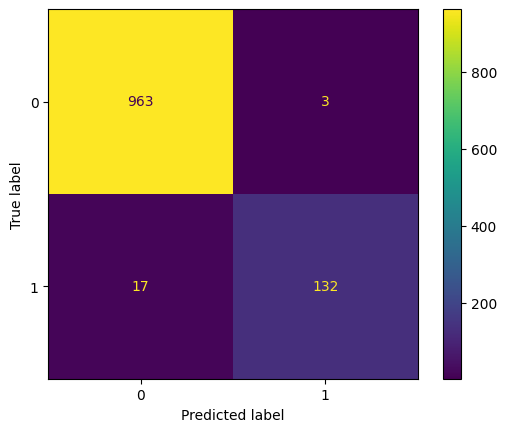

In [89]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test
)

plt.show()

In [90]:
import joblib

joblib.dump(best_model, "spam_model.joblib")
joblib.dump(tfidf, "tfidf_vectorizer.joblib")

['tfidf_vectorizer.joblib']